<a href="https://colab.research.google.com/github/HollySenior/GEOG5990/blob/main/Copy_of_GEOG5990M_Final_Project_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOG5990M Final Assignment

Student ID number: 201416775


Define problem: Do health promoting neighbourhoods have lower neighbourhood churn in Manchester?

In [1]:
# read in required packages
!pip install mapclassify
!pip install complexity
!pip install geoplot
!pip install git+https://github.com/pmdscully/geo_northarrow.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for complexity: filename=complexity-0.9.1-py3-none-any.whl size=13457 sha256=a29f5d64f25e17cdae271424ef14298a5846e69e1012adc55aa492b8db22ce1a
  Stored in directory: /root/.cache/pip/wheels/1b/43/22/f6394ce3bea53645f5d20a8000aef8237f97bd0612466673aa
Successfully built complexity
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 88.4 MB/s eta 0:00:00
  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-tb9qv2j7
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-tb9qv2j7
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit 963bdd271707a3bcaa47b2d83d92b88ae0b10950
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparin

In [2]:
# import relevant packages
import geopandas as gpd
import pandas as pd
import os
import matplotlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pyproj
import contextily as ctx
import geoplot as gplt
import geoplot.crs as gcrs
from geo_northarrow import add_north_arrow

Collect relevant data: uploading and reading in LSOA (2021) spatial data. LSOA ensure detailed and thorough analysis at the local level <a href="https://rss.onlinelibrary.wiley.com/doi/abs/10.1111/j.1467-985X.2009.00626.x">[1]</a>.

In [ ]:
# code used to connect to google drive to import LSOAs dataset
##from google.colab import drive
##drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# large LSOA (2021) file downloaded from:https://geoportal.statistics.gov.uk/datasets/2bbaef5230694f3abae4f9145a3a9800_0/explore
# saved in MyDrive and read in as a geojson file using geopandas package
## lsoa =gpd.read_file('/content/drive/MyDrive/Lower_layer_Super_Output_Areas_(December_2021)_Boundaries_EW_BFC_(V10).geojson')


In [ ]:
#check upload
# show top 5 rows of dataset
## lsoa.head()

,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,Shape__Area,Shape__Length,GlobalID,geometry
0,1,E01000001,City of London 001A,,532123,181632,51.51817,-0.097150,129865.314476,2635.767993,c625aea8-6d73-4b2a-be76-4d5c44cad9f8,"POLYGON ((-0.09665 51.52028, -0.09663 51.52025..."
1,2,E01000002,City of London 001B,,532480,181715,51.51883,-0.091970,228419.782242,2707.816821,52c878e9-ac68-4886-b4a8-fea9cd241a70,"POLYGON ((-0.08967 51.52069, -0.08971 51.52058..."
2,3,E01000003,City of London 001C,,532239,182033,51.52174,-0.095330,59054.204697,1224.573160,b9d8faca-d489-478d-8ce6-acaf76186d7d,"POLYGON ((-0.0965 51.52295, -0.09644 51.52282,..."
3,4,E01000005,City of London 001E,,533581,181283,51.51469,-0.076280,189577.709503,2275.805344,15e1417d-537c-4845-9820-fc7596bd59b0,"POLYGON ((-0.07568 51.51575, -0.07539 51.51555..."
4,5,E01000006,Barking and Dagenham 016A,,544994,184274,51.53875,0.089317,146536.995750,1966.092607,8a6c4ee0-c0ff-4736-9cfa-fb12a6d50da0,"POLYGON ((0.09125 51.53905, 0.0915 51.5389, 0...."


Pre-processing data: Edit LSOA dataset so only Manchester LSOAs are uploaded for analysis

In [ ]:
# code used to get LSOAs where name contains Manchester
## manchester = lsoa.loc[lsoa['LSOA21NM'].str.contains('Manchester'),:]
# save Manchester as a .geojson
##manchester.to_file('/content/drive/MyDrive/Manchester.geojson')


# read in Manchester geoJson from Google Drive
## manchester =gpd.read_file('/content/drive/MyDrive/Manchester.geojson')

In [ ]:
# check uploaded dataset is correct
# show top 5 rows of dataset
## manchester.head()

,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,Shape__Area,Shape__Length,GlobalID,geometry
0,4800,E01005061,Manchester 018A,,386335,397111,53.47057,-2.20733,862326.905121,5196.009180,71f23db3-ff86-459e-bf0c-4ccf53edd740,"POLYGON ((-2.1989 53.47175, -2.19872 53.47174,..."
1,4801,E01005063,Manchester 018C,,385853,396436,53.46449,-2.21456,284604.968887,5365.459117,04c953c8-a080-48ff-ace1-37a65cc32baf,"POLYGON ((-2.21023 53.46785, -2.21044 53.46739..."
2,4802,E01005065,Manchester 018D,,385314,397132,53.47073,-2.22271,659450.381119,5029.650902,bb78c9c6-15ec-477f-822e-273f3bb6222f,"POLYGON ((-2.21633 53.47353, -2.21632 53.47342..."
3,4803,E01005066,Manchester 018E,,384428,397188,53.47121,-2.23606,191389.854019,2621.399670,9d909f22-1223-4d91-b0f8-5daf71beaf75,"POLYGON ((-2.22971 53.47341, -2.22957 53.47324..."
4,4804,E01005067,Manchester 020A,,387120,396879,53.46850,-2.19549,396783.973190,3166.164473,6b7bcf7c-b8d9-4963-9ec0-dac7044e58ed,"POLYGON ((-2.19276 53.46871, -2.19275 53.4687,..."


In [3]:
# manchester file moved to github repo
#read in Manchester LSOAs datset from GitHub repo as a geojson file using geopandas package
manchester_lsoas = gpd.read_file('https://github.com/HollySenior/GEOG5990/raw/refs/heads/main/ManchesterLSOAs.geojson')

In [4]:
# checking upload has worked
# explore interactive leaflet map
manchester_lsoas.explore()

Collect relevant data: Read in Access to Healthy Assets & Hazards (AHAH) dataset via GitHub repo

In [5]:
# read in 'AHAH' dataset from gitHub repo as a csv file using panda package
# dataset sourced from CRDC website: https://data.cdrc.ac.uk/dataset/access-healthy-assets-hazards-ahah
## Data provided by the Consumer Data Research Centre, an ESRC Data Investment: ES/L011840/1, ES/L011891/1
ahah = pd.read_csv("https://github.com/HollySenior/GEOG5990/raw/refs/heads/main/AHAH_V4.csv")

In [6]:
# check upload
# show top 5 rows of dataset to understand rows and columns
ahah.head()

,LSOA21CD,ah4blue,ah4dent,ah4gp,ah4hosp,ah4phar,ah4leis,ah4pubs,ah4ffood,ah4gpas,...,ah4g_rnk,ah4e_rnk,ah4r_rnk,ah4h_pct,ah4g_pct,ah4e_pct,ah4r_pct,ah4ahah,ah4ahah_rnk,ah4ahah_pct
0,E01000001,1.8048,0.6328,1.0316,0.9581,0.7487,0.3596,0.4210,0.3920,0.1056,...,40830,42589,41495,2,96,100,98,59.7543,42592,100
1,E01000002,2.1041,0.6230,1.3232,1.1370,0.6849,0.5571,0.4852,0.3946,0.0778,...,42201,42590,41673,4,99,100,98,65.4344,42635,100
2,E01000003,2.2753,0.5709,0.8562,0.7862,0.5919,0.4608,0.5679,0.5919,0.1339,...,40631,42590,40857,1,96,100,96,57.4313,42559,100
3,E01000005,1.1553,0.8337,1.1078,0.8697,0.6657,0.3717,0.2673,0.2934,0.0774,...,40765,42616,42419,2,96,100,100,64.3384,42629,100
4,E01000006,1.9055,1.9361,0.9587,1.5191,1.3641,1.5219,1.5017,1.1499,0.3310,...,23517,41369,34909,22,56,98,82,33.5326,38389,91


Data cleaning for AHAH dataset: removing columns containing irrelevant data for this analysis to improve efficiency and focus of dataset analysis <a href="https://www.tableau.com/learn/articles/what-is-data-cleaning#definition">[2]</a>.

In [7]:
# identifying all column names in dataset to see which ones should be dropped
ahah.columns

Index(['LSOA21CD', 'ah4blue', 'ah4dent', 'ah4gp', 'ah4hosp', 'ah4phar',
       'ah4leis', 'ah4pubs', 'ah4ffood', 'ah4gpas', 'ah4tob', 'ah4gamb',
       'ah4no2', 'ah4so2', 'ah4pm10', 'ah4gp_rnk', 'ah4dent_rnk',
       'ah4phar_rnk', 'ah4hosp_rnk', 'ah4leis_rnk', 'ah4gpas_rnk',
       'ah4blue_rnk', 'ah4no2_rnk', 'ah4so2_rnk', 'ah4pm10_rnk', 'ah4gamb_rnk',
       'ah4pubs_rnk', 'ah4tob_rnk', 'ah4ffood_rnk', 'ah4gp_pct', 'ah4dent_pct',
       'ah4phar_pct', 'ah4hosp_pct', 'ah4leis_pct', 'ah4gpas_pct',
       'ah4blue_pct', 'ah4no2_pct', 'ah4so2_pct', 'ah4pm10_pct', 'ah4gamb_pct',
       'ah4pubs_pct', 'ah4tob_pct', 'ah4ffood_pct', 'ah4h', 'ah4g', 'ah4e',
       'ah4r', 'ah4h_rnk', 'ah4g_rnk', 'ah4e_rnk', 'ah4r_rnk', 'ah4h_pct',
       'ah4g_pct', 'ah4e_pct', 'ah4r_pct', 'ah4ahah', 'ah4ahah_rnk',
       'ah4ahah_pct'],
      dtype='object')

Variable dictionary from CDRC website (https://data.cdrc.ac.uk/dataset/access-healthy-assets-hazards-ahah/resource/variable-dictionary):

LSOA21CD:	Lower Super Output Area Code (2011)

LSOA21CD:	Data Zones (Scotland)

ah4blue:	Drive-time to nearest Bluespace (minutes)

ah4dent:	Drive-time to nearest Dentist (minutes)

ah4gp:	Drive-time to nearest GP Practice (minutes)

ah4hosp:	Drive-time to nearest Hospital (minutes)

ah4phar:	Drive-time to nearest Pharmacy (minutes)

ah4gpas:	NDVI value indicating Passive Green Space

ah4no2:	Annual mean Nitrogen Dioxide (ugm3)

ah4so2:	Annual mean Sulphur Dioxide (ugm3)

ah4pm10:	Annual mean Particulate Matter (ugm3)

ah4ffood:	Drive-time to nearest Fast Food Outlet (minutes)

ah4gamb:	Drive-time to nearest Gambling Outlet (minutes)

ah4pubs:	Drive-time to nearest Pubs/Bars/Nightclubs (minutes)

ah4tob:	Drive-time to nearest Tobacconists/Vape Store (minutes)

ah4leis:	Drive-time to nearest Leisure Centre (minutes)

ah4h:	Health Domain Score

ah4g:	Green/Bluespace Domain Score

ah4e:	Air Quality Domain Score

ah4r:	Retail Domain Score

ah4ahah:	Access to Healthy Assets and Hazards Index Score

ah4ahah_rnk:	AHAH Index Ranked

ah4ahah_pct:	AHAH Index percentiles


In [8]:
# drop variables in AHAH dataset so the resulting data frame includes only LSOA codes and AHAH index score, percentile and rank and 2 index domains (retail, health, greenspace, air quality)
# replace original dataframe
ahah = ahah.drop(['ah4blue', 'ah4dent', 'ah4gp', 'ah4hosp', 'ah4phar',
       'ah4leis', 'ah4pubs', 'ah4ffood', 'ah4gpas', 'ah4tob', 'ah4gamb',
       'ah4no2', 'ah4so2', 'ah4pm10', 'ah4gp_rnk', 'ah4dent_rnk',
       'ah4phar_rnk', 'ah4hosp_rnk', 'ah4leis_rnk', 'ah4gpas_rnk',
       'ah4blue_rnk', 'ah4no2_rnk', 'ah4so2_rnk', 'ah4pm10_rnk', 'ah4gamb_rnk',
       'ah4pubs_rnk', 'ah4tob_rnk', 'ah4ffood_rnk', 'ah4gp_pct', 'ah4dent_pct',
       'ah4phar_pct', 'ah4hosp_pct', 'ah4leis_pct', 'ah4gpas_pct',
       'ah4blue_pct', 'ah4no2_pct', 'ah4so2_pct', 'ah4pm10_pct', 'ah4gamb_pct',
       'ah4pubs_pct', 'ah4tob_pct', 'ah4ffood_pct','ah4h_rnk', 'ah4g_rnk', 'ah4e_rnk', 'ah4r_rnk', 'ah4h_pct',
       'ah4g_pct', 'ah4e_pct', 'ah4r_pct'], axis =1)


In [9]:
# check edit
# show top 5 rows of dataset
ahah.head()

,LSOA21CD,ah4h,ah4g,ah4e,ah4r,ah4ahah,ah4ahah_rnk,ah4ahah_pct
0,E01000001,-1.7834,0.9240,2.4705,1.7454,59.7543,42592,100
1,E01000002,-1.5523,1.2503,2.4736,1.8169,65.4344,42635,100
2,E01000003,-1.9813,0.8988,2.4736,1.5650,57.4313,42559,100
3,E01000005,-1.7260,0.9158,2.6345,2.2761,64.3384,42629,100
4,E01000006,-0.6686,0.0912,1.5218,0.7869,33.5326,38389,91


Pre-processing dataset: Join with Manchester LSOAs and check for null data

In [10]:
# join ahah (non spatial) dataset with Manchester LSOAs (spatial) dataset using pandas package
manchester_ahah = pd.merge(manchester_lsoas, ahah, left_on='LSOA21CD', right_on='LSOA21CD', how ='left')

In [11]:
#check join
# show top 5 rows of dataset
manchester_ahah.head()

,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,Shape__Area,Shape__Length,GlobalID,geometry,ah4h,ah4g,ah4e,ah4r,ah4ahah,ah4ahah_rnk,ah4ahah_pct
0,4800,E01005061,Manchester 018A,,386335,397111,53.47057,-2.20733,862326.905121,5196.009180,71f23db3-ff86-459e-bf0c-4ccf53edd740,"POLYGON ((-2.1989 53.47175, -2.19872 53.47174,...",-0.6938,0.4572,1.1376,-0.0222,27.1403,33241,78
1,4801,E01005063,Manchester 018C,,385853,396436,53.46449,-2.21456,284604.968887,5365.459117,04c953c8-a080-48ff-ace1-37a65cc32baf,"POLYGON ((-2.21023 53.46785, -2.21044 53.46739...",-1.3637,0.3595,1.1501,1.2862,35.3828,39288,93
2,4802,E01005065,Manchester 018D,,385314,397132,53.47073,-2.22271,659450.381119,5029.650902,bb78c9c6-15ec-477f-822e-273f3bb6222f,"POLYGON ((-2.21633 53.47353, -2.21632 53.47342...",-1.2923,0.3988,1.1502,0.7795,31.2813,36957,87
3,4803,E01005066,Manchester 018E,,384428,397188,53.47121,-2.23606,191389.854019,2621.399670,9d909f22-1223-4d91-b0f8-5daf71beaf75,"POLYGON ((-2.22971 53.47341, -2.22957 53.47324...",-0.8968,0.1608,1.0677,1.0217,30.1568,36103,85
4,4804,E01005067,Manchester 020A,,387120,396879,53.46850,-2.19549,396783.973190,3166.164473,6b7bcf7c-b8d9-4963-9ec0-dac7044e58ed,"POLYGON ((-2.19276 53.46871, -2.19275 53.4687,...",-0.9664,0.4113,1.0026,-0.0227,24.1898,29200,69


Data cleaning: check for unwanted outliers in AHAH dataset. Outliers can skew results in statistical data analysis and therefore mislead the interpreter, meaning it is important to check for outliers and determine if they are a result of error or not <a href="https://godatadrive.com/blog/outliers-101">[3]</a>.

<Axes: xlabel='ah4ahah'>

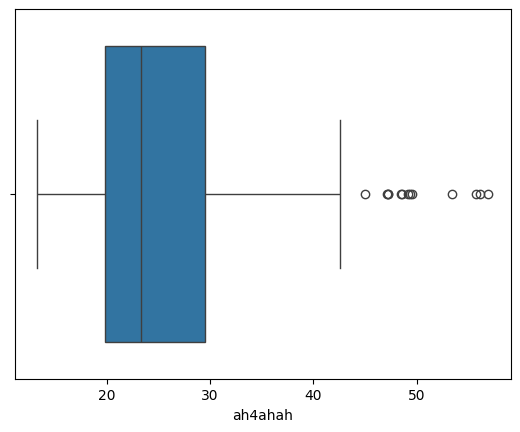

In [12]:
# visualise summary statistics and check for outliers with box plot of ahah data
sns.boxplot(x=manchester_ahah["ah4ahah"])

In [13]:
# explore summary statistics of ahah scores in Manchester LSOAs
# what is the mean?
# are there any extreme values/ outliers?
manchester_ahah['ah4ahah'].describe()

,ah4ahah
count,295.000000
mean,25.717725
std,8.447208
min,13.295600
25%,19.801800
50%,23.341200
75%,29.474000
max,56.927000


These outliers are deemed to be true outliers in this context as there are explanations for their existence <a href="https://godatadrive.com/blog/outliers-101">[3]</a>.

Data cleaning: check for null data

In [14]:
# check for null data in new dataframe
manchester_ahah.isna().any()

,0
FID,False
LSOA21CD,False
LSOA21NM,False
LSOA21NMW,False
BNG_E,False
BNG_N,False
LAT,False
LONG,False
Shape__Area,False
Shape__Length,False


In [15]:
# data exploration
# what is the size of the new dataset?
manchester_ahah.shape

(295, 19)

In [16]:
# explore descriptive statistics of ahah index percentiles across Manchester LSOAs
# can be compared with index statistics
manchester_ahah['ah4ahah_pct'].describe()

,ah4ahah_pct
count,295.000000
mean,65.535593
std,21.959872
min,14.000000
25%,49.500000
50%,66.000000
75%,84.000000
max,100.000000


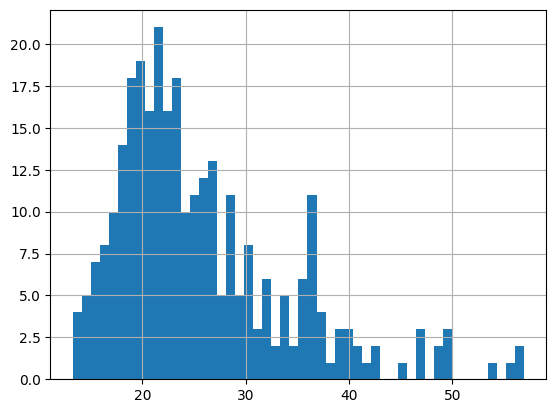

In [17]:
# explore distribution of ahah scores in Manchester via histogram (coninuous numercial data)
# adjust bins for more detail
manchester_ahah['ah4ahah'].hist(bins=50);

In [18]:
# explore data types and check they are as expected
manchester_ahah.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   FID            295 non-null    int32   
 1   LSOA21CD       295 non-null    object  
 2   LSOA21NM       295 non-null    object  
 3   LSOA21NMW      295 non-null    object  
 4   BNG_E          295 non-null    int32   
 5   BNG_N          295 non-null    int32   
 6   LAT            295 non-null    float64 
 7   LONG           295 non-null    float64 
 8   Shape__Area    295 non-null    float64 
 9   Shape__Length  295 non-null    float64 
 10  GlobalID       295 non-null    object  
 11  geometry       295 non-null    geometry
 12  ah4h           295 non-null    float64 
 13  ah4g           295 non-null    float64 
 14  ah4e           295 non-null    float64 
 15  ah4r           295 non-null    float64 
 16  ah4ahah        295 non-null    float64 
 17  ah4ahah_rnk    295 non-null

Validate clean: The AHAH dataset makes sense; all values are within reason and context; there are clear trends in the distribution of the data with most LSOA scores being in the 20s; and there are no null values.

Collect relevant data: Read in Residential Mobility Index

In [19]:
# read in Residential Mobility Index (AKA neighbourhood 'churn') dataset from gitHub repo as a csv file using panda package
# dataset sourced from CRDC website: https://data.cdrc.ac.uk/dataset/cdrc-residential-mobility-index
## Data provided by the Consumer Data Research Centre, an ESRC Data Investment: ES/L011840/1, ES/L011891/1
churn = pd.read_csv("https://github.com/HollySenior/GEOG5990/raw/refs/heads/main/hh_churn_lsoa11_2023.csv")

In [20]:
# check upload
# show topp 5 rows of dataset
churn.head()

,area,chn1997,chn1998,chn1999,chn2000,chn2001,chn2002,chn2003,chn2004,chn2005,...,chn2014,chn2015,chn2016,chn2017,chn2018,chn2019,chn2020,chn2021,chn2022,chn2023
0,95AA01S1,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,0.969,0.928,0.914,0.879,0.799,0.723,0.537,0.290,0
1,95AA01S2,0.663,0.651,0.636,0.629,0.618,0.603,0.590,0.569,0.541,...,0.416,0.397,0.373,0.336,0.287,0.256,0.244,0.186,0.102,0
2,95AA01S3,0.700,0.688,0.671,0.663,0.653,0.633,0.611,0.591,0.570,...,0.453,0.435,0.412,0.367,0.310,0.279,0.266,0.182,0.072,0
3,95AA02W1,0.591,0.576,0.560,0.549,0.542,0.537,0.534,0.529,0.524,...,0.387,0.362,0.331,0.297,0.262,0.243,0.233,0.172,0.087,0
4,95AA03W1,0.602,0.591,0.586,0.584,0.581,0.569,0.554,0.541,0.524,...,0.398,0.371,0.337,0.304,0.270,0.252,0.244,0.177,0.081,0


In [21]:
# check data types of dataset
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42619 entries, 0 to 42618
Data columns (total 28 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   area     42619 non-null  object 
 1   chn1997  42619 non-null  float64
 2   chn1998  42619 non-null  float64
 3   chn1999  42619 non-null  float64
 4   chn2000  42619 non-null  float64
 5   chn2001  42619 non-null  float64
 6   chn2002  42619 non-null  float64
 7   chn2003  42619 non-null  float64
 8   chn2004  42619 non-null  float64
 9   chn2005  42619 non-null  float64
 10  chn2006  42619 non-null  float64
 11  chn2007  42619 non-null  float64
 12  chn2008  42619 non-null  float64
 13  chn2009  42619 non-null  float64
 14  chn2010  42619 non-null  float64
 15  chn2011  42619 non-null  float64
 16  chn2012  42619 non-null  float64
 17  chn2013  42619 non-null  float64
 18  chn2014  42619 non-null  float64
 19  chn2015  42619 non-null  float64
 20  chn2016  42619 non-null  float64
 21  chn2017  426

Pre-processing dataset: The RMI ('churn') dataset is available at 2011 LSOA boundaries or 2021 LAD boundaries. In this analysis the 2011 LSOA boundaries are used due to the smaller scale and similarities with 2021 LSOA boundaries. Therefore the 2011 LSOA boundaries are uploaded, clipped to Manchester and joined with RMI ('churn') dataset.

In [ ]:
# large LSOA (2011) file downloaded from:https://geoportal.statistics.gov.uk/datasets/357ee15b1080431491bf965394090c72_0/explore?location=52.611120%2C-2.489527%2C6.19
# saved in MyDrive and read in as a geopackage file using geopandas package
##lsoa2011 =gpd.read_file('/content/drive/MyDrive/Lower_Layer_Super_Output_Areas_Dec_2011_Boundaries_Full_Extent_BFE_EW_V3_2022_-2724249557619198582.gpkg')
##lsoa2011.head()

In [ ]:
# code used to get 2011 LSOAs where name contains Manchester
##manchester2011 = lsoa2011.loc[lsoa2011['LSOA11NM'].str.contains('Manchester'),:]
# save Manchester as a .geojson
##manchester2011.to_file('/content/drive/MyDrive/Manchester2011.geojson')


# read in Manchester geoJson from Google Drive
##manchester2011 =gpd.read_file('/content/drive/MyDrive/Manchester.geojson')

In [22]:
# manchester2011 file moved to github repo
#read in Manchester 2011 LSOAs datset from GitHub repo as a geojson file using geopandas package
manchester_lsoas2011 = gpd.read_file('https://github.com/HollySenior/GEOG5990/raw/refs/heads/main/Manchester2011.geojson')

In [23]:
# check size of Manchester 2011 LSOA dataset
manchester_lsoas2011.shape

(282, 9)

In [24]:
# join churn (non spatial) dataset with Manchester 2011 LSOAs (spatial) dataset using pandas package
manchester2011_churn = pd.merge(manchester_lsoas2011, churn, left_on='LSOA11CD', right_on='area', how ='left')

In [25]:
#check for null data in new dataframe
manchester2011_churn.isna().sum()

,0
LSOA11CD,0
LSOA11NM,0
BNG_E,0
BNG_N,0
LONG_,0
LAT,0
Shape_Leng,0
GlobalID,0
geometry,0
area,0


In [26]:
# check data types
manchester2011_churn.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 37 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LSOA11CD    282 non-null    object  
 1   LSOA11NM    282 non-null    object  
 2   BNG_E       282 non-null    int32   
 3   BNG_N       282 non-null    int32   
 4   LONG_       282 non-null    float64 
 5   LAT         282 non-null    float64 
 6   Shape_Leng  282 non-null    float64 
 7   GlobalID    282 non-null    object  
 8   geometry    282 non-null    geometry
 9   area        282 non-null    object  
 10  chn1997     282 non-null    float64 
 11  chn1998     282 non-null    float64 
 12  chn1999     282 non-null    float64 
 13  chn2000     282 non-null    float64 
 14  chn2001     282 non-null    float64 
 15  chn2002     282 non-null    float64 
 16  chn2003     282 non-null    float64 
 17  chn2004     282 non-null    float64 
 18  chn2005     282 non-null    float64 
 19  

All churn data columns (13 to 39) have non-null values; therefore, I will drop all columns except chn2018 because this represents the proportion of households that have changed between 2018 and 2023. A five-year interval is a representative period for assessing neighbourhood churn <a href="https://www.jstor.org/stable/41958940?seq=1">[4]</a>.

In [27]:
# drop all variable columns representing the proportion of properties that have changed occupants between 1997 and beginning of 2023, except for 2018
manchester2011_churn_1823 = manchester2011_churn.drop(['chn1997', 'chn1998', 'chn1999', 'chn2000', 'chn2001', 'chn2002',
       'chn2003', 'chn2004', 'chn2005', 'chn2006', 'chn2007', 'chn2008',
       'chn2009', 'chn2010', 'chn2011', 'chn2012', 'chn2013', 'chn2014',
       'chn2015', 'chn2016', 'chn2017','chn2019', 'chn2020',
       'chn2021', 'chn2022', 'chn2023'], axis =1)

Pre-processing: edit RMI columns to show percentage of LSOA households that have changed instead of proportion for a more clear analysis

In [28]:
# multiply neighbourhood 'churn' 2018-2023 column by 100 to convert to percentage of LSOA households
manchester2011_churn_1823['chn2018'] =manchester2011_churn_1823['chn2018'].multiply(100)

In [29]:
# check edit
# show top 5 rows of dataset
manchester2011_churn_1823.head()

,LSOA11CD,LSOA11NM,BNG_E,BNG_N,LONG_,LAT,Shape_Leng,GlobalID,geometry,area,chn2018
0,E01005061,Manchester 018A,386335,397111,-2.20732,53.470600,5196.009141,{C5F42864-5545-4E28-9E48-3A3EB0A6B0DF},"MULTIPOLYGON (((386894.4 397240.187, 386885.09...",E01005061,17.0
1,E01005062,Manchester 018B,385120,396466,-2.22559,53.464699,6132.029869,{B074A2C6-85F7-4D0D-BD99-AF76330A62FD},"MULTIPOLYGON (((384601 397195, 384601.938 3972...",E01005062,37.2
2,E01005063,Manchester 018C,385853,396436,-2.21455,53.464500,5365.459117,{273A4867-D9C7-487D-A2B1-6EB2FF709FD2},"MULTIPOLYGON (((386140.989 396808.79, 386141.7...",E01005063,24.8
3,E01005065,Manchester 018D,385314,397132,-2.22270,53.470699,5029.650902,{EA9CEA99-9A20-43C8-978D-7C74DDE9E140},"MULTIPOLYGON (((385738 397442, 385734.788 3974...",E01005065,30.1
4,E01005066,Manchester 018E,384428,397188,-2.23605,53.471199,2621.399670,{D93AB4FA-D473-495D-8F5F-7EC6521C0DC8},"MULTIPOLYGON (((384850 397432, 384850 397434, ...",E01005066,37.5


Data cleaning: check for outliers

In [30]:
# explore summary statistics of 2018-2023 neighbourhood churn data
# what is the mean? are there any outliers?
manchester2011_churn_1823['chn2018'].describe()

,chn2018
count,282.000000
mean,30.728014
std,17.297253
min,9.700000
25%,18.450000
50%,24.550000
75%,37.050000
max,85.200000


<Axes: xlabel='chn2018'>

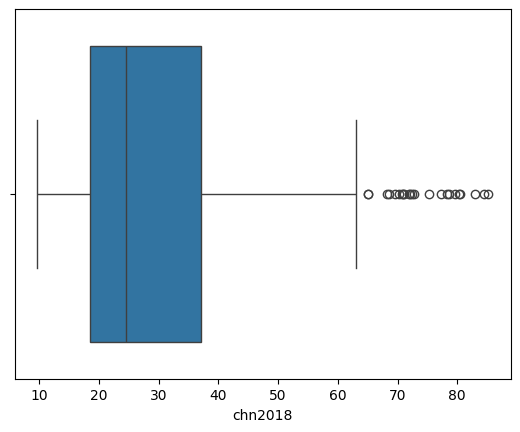

In [31]:
# visualise summary statistics and check for outliers with box plot of 'churn' data
sns.boxplot(x=manchester2011_churn_1823["chn2018"])

Outliers are present but are within reason in the context of the dataset - all values are below 100%. Therefore, these are left in as true outliers.

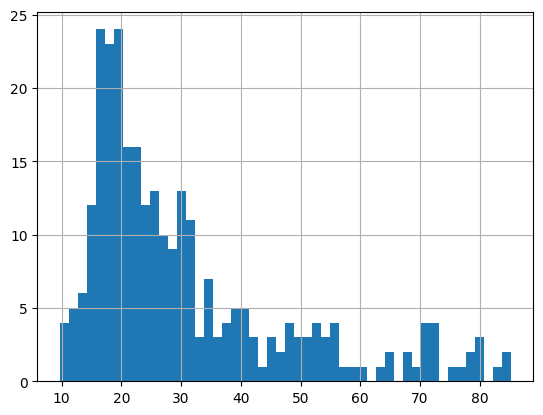

In [32]:
# visually explore distribution of neighbourhood 'churn' in Manchester via histogram
# edit bins to improve detail
manchester2011_churn_1823['chn2018'].hist(bins=50);

The RMI dataset is clean and clear trends in the distribution of data values is present with 18-20% household change in LSOAs across Manchester.

Pre-processing: Join RMI and churn datasets for comparison of variables. When comparing two spatial datasets it is essential to ensure coordinate references systems are the same.

In [33]:
# check coordinate reference system for both variable datasets before joining/ comparing plots
print(manchester2011_churn_1823.crs, manchester_ahah.crs)

EPSG:27700 EPSG:4326


In [34]:
# edit crs for manchester_ahah dataset to match manchester2011_churn_1823 dataset (British National Grid)
manchester_ahah_newproj = manchester_ahah.to_crs(epsg=27700)

In [35]:
# check edit
manchester_ahah_newproj.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

Pre-processing: Join RMI and AHAH datasets and explore null values

In [36]:
## join RMI and AHAH datasets for statistical analysis
manchester_churn_ahah = pd.merge(manchester2011_churn_1823, manchester_ahah_newproj, left_on='LSOA11CD', right_on='LSOA21CD', how ='left')

In [37]:
# check size of dataframe
manchester_churn_ahah.shape

(282, 30)

In [38]:
manchester_churn_ahah.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   LSOA11CD       282 non-null    object  
 1   LSOA11NM       282 non-null    object  
 2   BNG_E_x        282 non-null    int32   
 3   BNG_N_x        282 non-null    int32   
 4   LONG_          282 non-null    float64 
 5   LAT_x          282 non-null    float64 
 6   Shape_Leng     282 non-null    float64 
 7   GlobalID_x     282 non-null    object  
 8   geometry_x     282 non-null    geometry
 9   area           282 non-null    object  
 10  chn2018        282 non-null    float64 
 11  FID            263 non-null    float64 
 12  LSOA21CD       263 non-null    object  
 13  LSOA21NM       263 non-null    object  
 14  LSOA21NMW      263 non-null    object  
 15  BNG_E_y        263 non-null    float64 
 16  BNG_N_y        263 non-null    float64 
 17  LAT_y          263 non-null

In [39]:
# identify null values
# these will be as a result of the differences in 2011 and 2021 LSOA boundaries
manchester_churn_ahah.isna().sum()

,0
LSOA11CD,0
LSOA11NM,0
BNG_E_x,0
BNG_N_x,0
LONG_,0
LAT_x,0
Shape_Leng,0
GlobalID_x,0
geometry_x,0
area,0


Due to the limitations in comparing LSOA data from 2011 and 2021, this analysis will solely focus on the unchanged Manchester LSOAs. Therefore, the null values will be dropped. This means information will be lost; however, there are still 263 observations (LSOAs), meaning results can still be drawn.

In [40]:
# drop null values
manchester_churn_ahah_drop = manchester_churn_ahah.dropna()

In [41]:
# check drop has worked
manchester_churn_ahah_drop.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 263 entries, 0 to 281
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   LSOA11CD       263 non-null    object  
 1   LSOA11NM       263 non-null    object  
 2   BNG_E_x        263 non-null    int32   
 3   BNG_N_x        263 non-null    int32   
 4   LONG_          263 non-null    float64 
 5   LAT_x          263 non-null    float64 
 6   Shape_Leng     263 non-null    float64 
 7   GlobalID_x     263 non-null    object  
 8   geometry_x     263 non-null    geometry
 9   area           263 non-null    object  
 10  chn2018        263 non-null    float64 
 11  FID            263 non-null    float64 
 12  LSOA21CD       263 non-null    object  
 13  LSOA21NM       263 non-null    object  
 14  LSOA21NMW      263 non-null    object  
 15  BNG_E_y        263 non-null    float64 
 16  BNG_N_y        263 non-null    float64 
 17  LAT_y          263 non-null    f

In [42]:
# check join
# show top 5 rows of dataset
manchester_churn_ahah_drop.head()

,LSOA11CD,LSOA11NM,BNG_E_x,BNG_N_x,LONG_,LAT_x,Shape_Leng,GlobalID_x,geometry_x,area,...,Shape__Length,GlobalID_y,geometry_y,ah4h,ah4g,ah4e,ah4r,ah4ahah,ah4ahah_rnk,ah4ahah_pct
0,E01005061,Manchester 018A,386335,397111,-2.20732,53.470600,5196.009141,{C5F42864-5545-4E28-9E48-3A3EB0A6B0DF},"MULTIPOLYGON (((386894.4 397240.187, 386885.09...",E01005061,...,5196.009180,71f23db3-ff86-459e-bf0c-4ccf53edd740,"POLYGON ((386894.509 397241.969, 386907.014 39...",-0.6938,0.4572,1.1376,-0.0222,27.1403,33241.0,78.0
2,E01005063,Manchester 018C,385853,396436,-2.21455,53.464500,5365.459117,{273A4867-D9C7-487D-A2B1-6EB2FF709FD2},"MULTIPOLYGON (((386140.989 396808.79, 386141.7...",E01005063,...,5365.459117,04c953c8-a080-48ff-ace1-37a65cc32baf,"POLYGON ((386141.104 396810.582, 386127.4 3967...",-1.3637,0.3595,1.1501,1.2862,35.3828,39288.0,93.0
3,E01005065,Manchester 018D,385314,397132,-2.22270,53.470699,5029.650902,{EA9CEA99-9A20-43C8-978D-7C74DDE9E140},"MULTIPOLYGON (((385738 397442, 385734.788 3974...",E01005065,...,5029.650902,bb78c9c6-15ec-477f-822e-273f3bb6222f,"POLYGON ((385738.131 397443.782, 385739.131 39...",-1.2923,0.3988,1.1502,0.7795,31.2813,36957.0,87.0
4,E01005066,Manchester 018E,384428,397188,-2.23605,53.471199,2621.399670,{D93AB4FA-D473-495D-8F5F-7EC6521C0DC8},"MULTIPOLYGON (((384850 397432, 384850 397434, ...",E01005066,...,2621.399670,9d909f22-1223-4d91-b0f8-5daf71beaf75,"POLYGON ((384850.14 397433.795, 384859.139 397...",-0.8968,0.1608,1.0677,1.0217,30.1568,36103.0,85.0
5,E01005067,Manchester 020A,387120,396879,-2.19549,53.468498,3166.164433,{7B98C25B-7505-4948-B374-E925813F683E},"MULTIPOLYGON (((387301.245 396901.348, 387298....",E01005067,...,3166.164473,6b7bcf7c-b8d9-4963-9ec0-dac7044e58ed,"POLYGON ((387301.346 396903.134, 387302.183 39...",-0.9664,0.4113,1.0026,-0.0227,24.1898,29200.0,69.0


Statistical analysis: Explore relationship between neighbourhood 'churn' from 2018 to 2023 and AHAH index scores across Manchester LSOAs using Pearson correlation. Pearson correlation coefficient was used as it determines the "strength of a linear relationship between two variables" <a href="https://uk.surveymonkey.com/market-research/resources/pearson-correlation-vs-spearman-correlation/">[5]</a>.

In [43]:
# calculate correlation between neighbourhood churn and ahah scores across Manchester LSOAs using Spearman's method
manchester_churn_ahah_drop[['chn2018','ah4ahah', "ah4g","ah4e","ah4r","ah4h"]].corr(method = 'pearson')

,chn2018,ah4ahah,ah4g,ah4e,ah4r,ah4h
chn2018,1.000000,0.507642,0.239309,0.423880,0.503126,-0.441387
ah4ahah,0.507642,1.000000,0.775746,0.605474,0.759628,-0.609305
ah4g,0.239309,0.775746,1.000000,0.299405,0.384611,-0.395358
ah4e,0.423880,0.605474,0.299405,1.000000,0.343056,-0.423026
ah4r,0.503126,0.759628,0.384611,0.343056,1.000000,-0.756551
ah4h,-0.441387,-0.609305,-0.395358,-0.423026,-0.756551,1.000000


Correlation analysis using the pandas corr() method is suitable for identifying and quantifying relationships between numeric variables <a href="https://www.perlego.com/book/4193/mastering-python-data-visualization-pdf">[6]</a>. The overall AHAH score and RMI (2018-2023) have a moderately strong, positive relationship, meaning that larger AHAH scores (LSOAs with poorer health-related environments) are associated with greater neighbourhood 'churn'. In terms of the domains, green/ blue spaces are weakly related to RMI; air quality and retail show a moderate, positive relationship; and health shows a moderate, negative relationship with neighbourhood 'churn'.

Data Visualisation

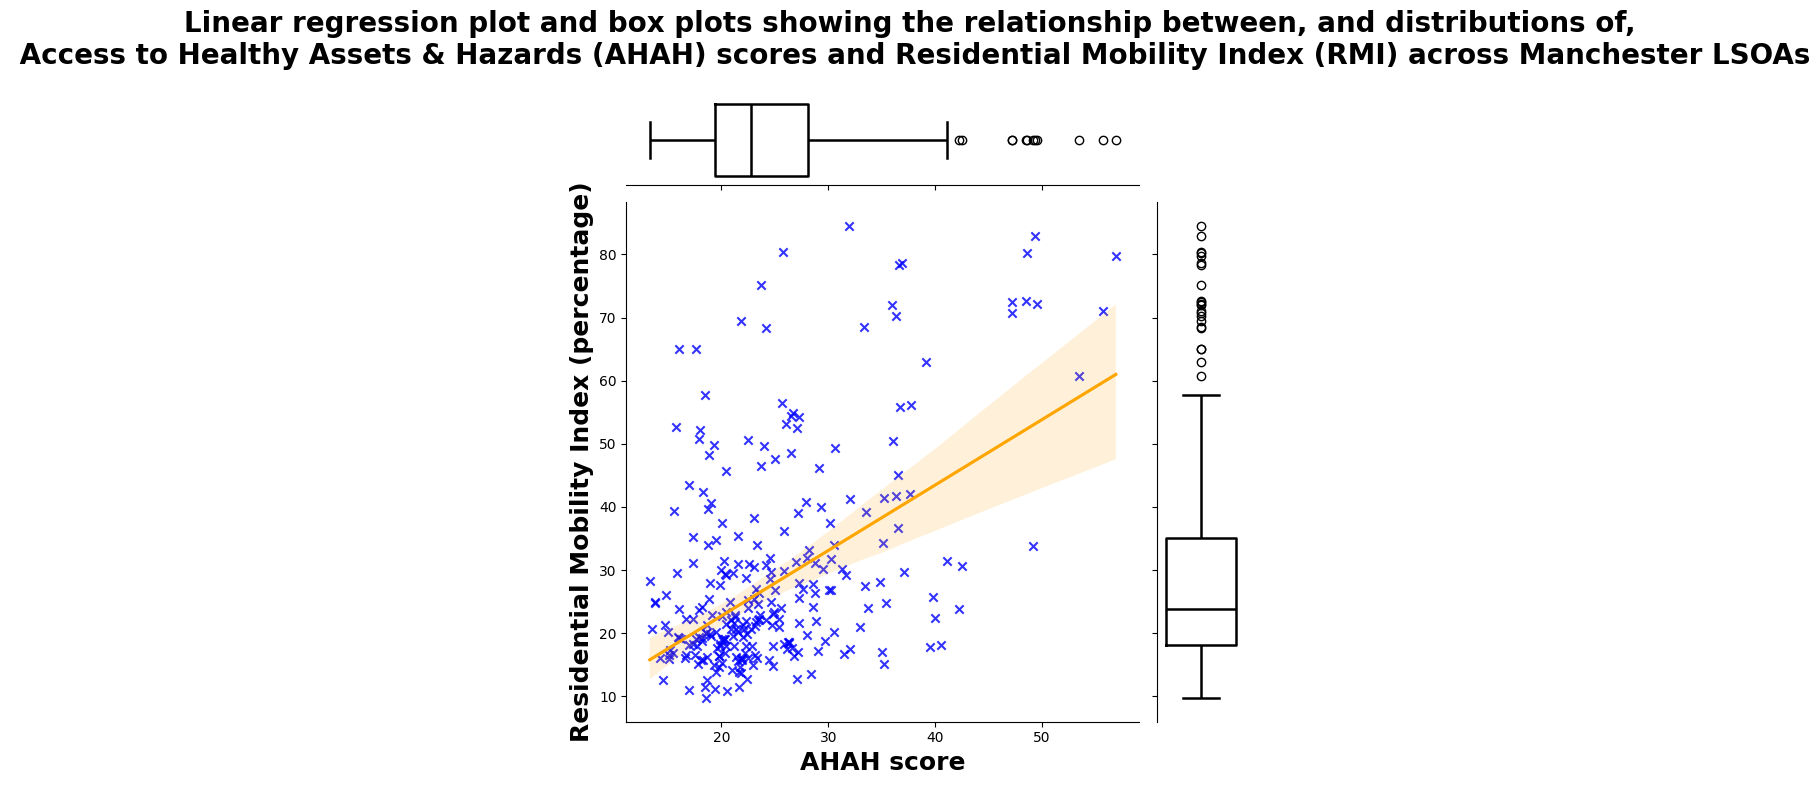

In [45]:
#non-spatial data visualisation:
# showing relationship between residential mobility index and access to health assets and hazards scores across Manchester LSOAs using seaborn JointGrid function and linear regression plot and box plots
g = sns.JointGrid(data=manchester_churn_ahah, dropna= True, #drop missing values before plotting
                 x="ah4ahah",# set x-axis variable as AHAH score
                 y="chn2018", # set y-axis variable at neighbourhood 'churn' 2018-2023
                 height=7, # set height of plot
                  palette ='colorblind')# use colourblind friendly palette
g.plot_joint(sns.regplot, robust=True, # robust regression to downweight outliers
            marker = "x", # edit marker appearance
             color = "b",
             line_kws = dict(color="orange")) # change colors
g.plot_marginals(sns.boxplot, fill = False, color = "0", linewidth =1.8) # edit elements of boxplots to match regression plot

#adjust plot axis titles
g.set_axis_labels('AHAH score','Residential Mobility Index (percentage)', fontsize = 18, fontweight ='bold')

# set figure title and edit placement, size and style, and set over two lines
g.fig.suptitle("Linear regression plot and box plots showing the relationship between, and distributions of,\n Access to Healthy Assets & Hazards (AHAH) scores and Residential Mobility Index (RMI) across Manchester LSOAs", x=0.5, y=1.1, fontsize=20, fontweight ='bold')

plt.show();

This data visualisation uses the Residential Mobility Index dataset and Access to Healthy Assets and Hazards dataset to demonstrate the relationship between neighbourhood 'churn' between 2018 and 2023 and AHAH scores across LSOAs in Manchester. The Seaborn JointGrid function was used to combine a linear regression plot with box plots for both variables. The linear regression plot shows the moderate, positive relationship between the two continuous numeric variables with the regression line and a 95% confidence interval <a href="https://seaborn.pydata.org/archive/0.11/tutorial/regression.html">[7]</a>. However, most of the data points (LSOAs) are clustered in the bottom left-hand corner of the plot suggesting that this relationship is a result of outliers in the dataset. In the data exploration process, it was found that both datasets contained outiers, therefore the regression model is paired with box plots for each variable, showing the distribution of the continuous numerical data. Box plots are appropriate for displaying medians, quartiles as well as outliers in datasets <a href="https://www.perlego.com/book/4287/python-data-visualization-cookbook-second-edition-pdf">[8]</a>. Outliers  can be responsible for sqewing the results and so this visualisation is made robust by downweighing the influence of outliers. The visualisation is accessible to any colourblind viewers and the visualisation elements were edited to make the trend line clearer to the audience.
Despite dropping 19 null rows after joining the two datasets due to differing LSOA dates, a significant number of datapoints were still plotted. Therefore, this visualisation is limited as it only represented Manchester LSOAs that were not changed between 2011 and 2021.
This visualisation is designed for an academic audience due to the more advanced regression and box plots. While it demonstrates a moderate relationship between the two variables, it can still be deemed valid as preliminary analysis and worthy of further investigation. Furthermore, it also highlights the LSOAs standing out as outliers in both variable datasets, which could be identified and investigated further. Most of the points are situated in the bottom left corner of the graph, meaning most Manchester LSOAs had low neighbourhood 'churn' between 2018 and 2023 and health promoting environments (low AHAH scores). Therefore, it can be deduced that health promoting LSOAs have lower residential mobility.

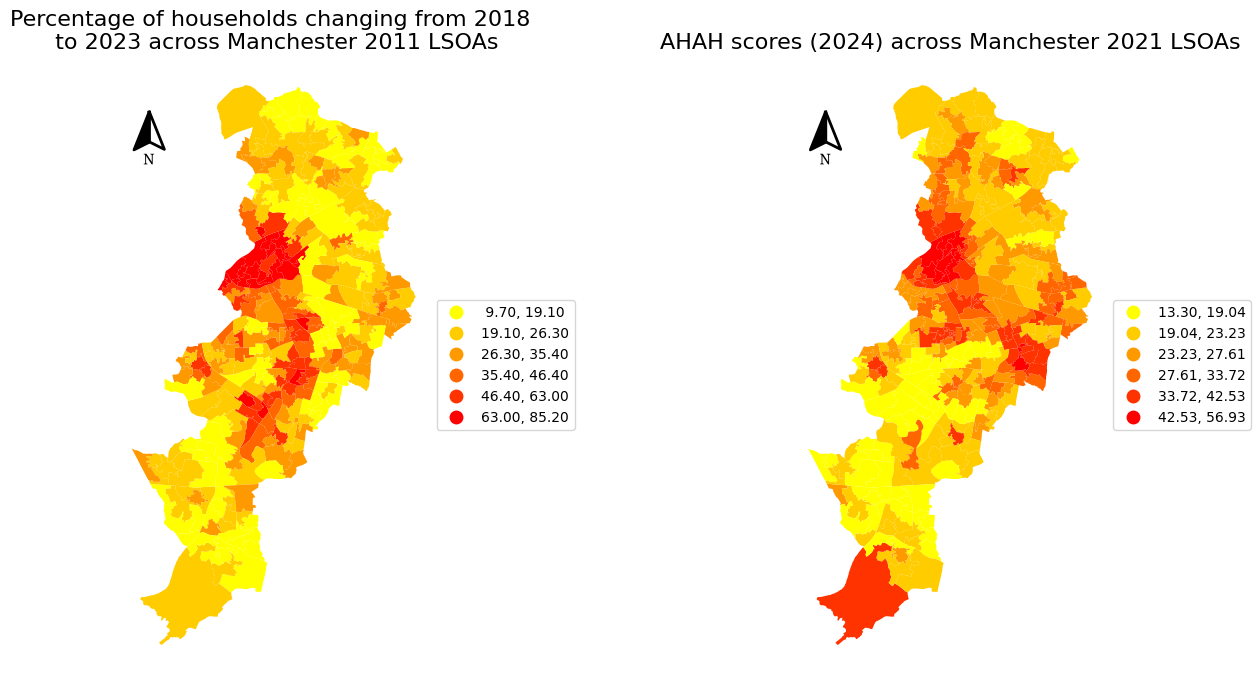

In [46]:
# spatial data visualisation
# create a figure with 2 subplots (for AHAH score and RMI percentage)
f, ax = plt.subplots (1,2, figsize = (16,8))


# subplot 1
# choropleth map of neighbourhood 'churn' across Manchester 2011 LSOAs
manchester2011_churn_1823.plot(ax=ax[0], column ='chn2018', legend = True,
                               cmap = 'autumn_r',# colourblind friendly sequential colourbar
                            scheme = 'natural_breaks', k = 6, legend_kwds={"loc": "center left", "bbox_to_anchor": (1, 0.5)})
# set title and adjust font size
ax[0].set_title('Percentage of households changing from 2018 \n to 2023 across Manchester 2011 LSOAs', fontsize = 16)
# remove axis
ax[0].set_axis_off()
# add north arrow and arrange placement
add_north_arrow(ax=ax[0], scale=.75, xlim_pos=0.1, ylim_pos=.85, color='#000', text_scaler=2, text_yT=-1.25)

#subplot 2
# choropleth map of AHAH scores across Manchester 2021 LSOAs
manchester_ahah_newproj.plot(ax=ax[1], column = 'ah4ahah', legend = True,
                             cmap = 'autumn_r',  #colourblind friendly sequential colourbar
                             scheme = 'natural_breaks', k = 6, legend_kwds={"loc": "center left", "bbox_to_anchor": (1, 0.5)})

# set title and adjust font size
ax[1].set_title('AHAH scores (2024) across Manchester 2021 LSOAs', fontsize = 16)
# remove axis
ax[1].set_axis_off()
# add north arrow and arrange placement
add_north_arrow(ax=ax[1], scale=.75, xlim_pos=0.1, ylim_pos=.85, color='#000', text_scaler=2, text_yT=-1.25)

plt.show();

The first subplot presents a choropleth map showing the percentage of households that have changed between 2018 and 2023 across 2011 Manchester LSOAs and the second shows the 2024 AHAH scores of 2021 Manchester LSOAs. Choropleth maps are appropriate for demonstrating spatial patterns of numerical data across a geographical area. The colorbars use a colourblind friendly palette, making the visualisation accessible. Viewers can also make assumptions about visualisations based on the colour scheme; therefore, a sequential scheme is used which is almost monochromatic (yellow to red)  <a href="https://www.perlego.com/book/4287/python-data-visualization-cookbook-second-edition-pdf">[8]</a>. Low values are represented by lighter colours (yellow) and higher values by darker colours (red). The choropleth maps are both classified according to a natural breaks scheme, which minimises within-class variation and maximises between-class differences <a href="https://geopandas.org/en/stable/gallery/choropleths.html">[9]</a>. This visualisation was chosen as spatial trends of both datasets can be visualised and compared. Additionally, the outliers in both datasets can be identified in the area. For instance, Manchester city centre shows high scores for both datasets, meaning these LSOAs have a high percentage of household change and poor health environments. This spatial data visualisation aims to be accessible to policy makers to highlight LSOAs with poor health related environments (high AHAH scores) and high household turnover. Although there are many factors which can influence residential mobility <a href="https://rss.onlinelibrary.wiley.com/doi/abs/10.1111/j.1467-985X.2009.00626.x">[1]</a>, this visualisation demonstrates the spatial relationship between health promoting neighbourhoods and neighbourhood 'churn'.

## References
<p><a href="https://rss.onlinelibrary.wiley.com/doi/abs/10.1111/j.1467-985X.2009.00626.x">[1]</a>Rabe, B. and Taylor, M. 2010. Residential mobility, quality of neighbourhood and
life course events. Journal of the Royal Statistical Society Series A: Statistics in Society. 173(3), pp.531-555.
</p>
<p><a href="https://www.tableau.com/learn/articles/what-is-data-cleaning#definition ">[2]</a>Tableau, 2025. Guide To Data Cleaning: Definition, Benefits, Components, And How To Clean Your Data. [Online]
Available at: https://www.tableau.com/learn/articles/what-is-data-cleaning#definition
[Accessed 1 May 2025].

</p>
<p><a href="https://godatadrive.com/blog/outliers-101">[3]</a>Drive, D., 2022. A Basic Guide to Outlier. [Online]
Available at: https://godatadrive.com/blog/outliers-101
[Accessed 13 April 2025].
</p>
<p><a href="https://www.jstor.org/stable/41958940?seq=1 ">[4]</a>Coulton, C., Theodos, B. and Turner, M.A. 2012. Residential mobility and neighbourhood change: Real neighbourhoods under the microscope. Cityscape. 14(3), pp.55-89.</p>
<p><a href="https://uk.surveymonkey.com/market-research/resources/pearson-correlation-vs-spearman-correlation/">[5]</a>Monkey, S., 2025. Pearson correlation vs. Spearman correlation methods. [Online]
Available at: https://uk.surveymonkey.com/market-research/resources/pearson-correlation-vs-spearman-correlation/
[Accessed 1 May 2025].
</p>
<p><a href="https://www.perlego.com/book/4193/mastering-python-data-visualization-pdf">[6]</a>Raman, K., 2015. In: Mastering Python Data Visualisation. Birmingham: Packt.</p>
<p><a href="https://seaborn.pydata.org/archive/0.11/tutorial/regression.html ">[7]</a>Seaborn, 2021. Visualising regression models. [Online]
Available at: https://seaborn.pydata.org/archive/0.11/tutorial/regression.html
[Accessed 28 April 2025].
</p>
<p><a href=" https://www.perlego.com/book/4287/python-data-visualization-cookbook-second-edition-pdf">[8]</a>Milovanovic, I., Foures, D. & Vettigli, G., 2015. In: Python Data Visualization Cookbook - Second Edition. s.l.:Packt.</p>
<p><a href="https://geopandas.org/en/stable/gallery/choropleths.html">[9]</a>GeoPandas, 2025. Choropleth classification schemes from PySAL for use with GeoPandas. [Online]
Available at: https://geopandas.org/en/stable/gallery/choropleths.html
[Accessed 15 April 2025].

</p>